In [1]:
import starry
import matplotlib.pyplot as plt
import numpy as np
import pymc3 as pm
import pymc3.math as pmm
import pymc3_ext as pmx
import exoplanet
from starry_process import StarryProcess, MCMCInterface
from starry_process.math import cho_factor, cho_solve
import starry_process 
import theano
theano.config.gcc__cxxflags += " -fexceptions"
theano.config.on_opt_error = "raise"
theano.tensor.opt.constant_folding
theano.graph.opt.EquilibriumOptimizer
import aesara_theano_fallback.tensor as tt
from theano.tensor.slinalg import cholesky
from corner import corner
import arviz as az
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import os
from tqdm import tqdm
from theano.tensor.random.utils import RandomStream
import scipy.linalg as sl
import scipy.stats as ss
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.linalg import svd

starry.config.quiet = True
np.random.seed(1)

WARNING (theano.link.c.cmodule): install mkl with `conda install mkl-service`: No module named 'mkl'
The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.


In [2]:
import sys
sys.path.insert(1, '../../scripts')

from starry_starry_process import StarryStarryProcess

In [9]:
class Star(object):
    starry.config.lazy = False
    def __init__(
        self, t, error=1e-8, nlon=300, ydeg=15, linear=True, eps=1e-12, smoothing=0.1, planet=True
    ):
        # Generate a uniform intensity grid
        self.nlon = nlon
        self.nlat = nlon // 2
        self.lon = np.linspace(-180, 180, self.nlon)
        self.lat = np.linspace(-90, 90, self.nlat)
        self.lon, self.lat = np.meshgrid(self.lon, self.lat)
        self.intensity = np.zeros_like(self.lat)
        self.linear = linear
        self.t = t
        self.err = error

        # Instantiate a starry map
        self.map = starry.Map(ydeg, 2)

        # cos(lat)-weighted SHT
        w = np.cos(self.lat.flatten() * np.pi / 180)
        P = self.map.intensity_design_matrix(
            lat=self.lat.flatten(), lon=self.lon.flatten()
        )
        PTSinv = P.T * (w ** 2)[None, :]
        self.Q = np.linalg.solve(PTSinv @ P + eps * np.eye(P.shape[1]), PTSinv)
        if smoothing > 0:
            l = np.concatenate(
                [np.repeat(l, 2 * l + 1) for l in range(ydeg + 1)]
            )
            s = np.exp(-0.5 * l * (l + 1) * smoothing ** 2)
            self.Q *= s[:, None]

        self.star = starry.Primary(self.map, r=1, m=1) 
        self.map[1] = 0.4
        self.map[2] = 0.2
        if planet:
            self.planet = starry.Secondary(
                starry.Map(0,0),
                inc=90,
                ecc=0,
                r=0.1,
                m=1e-3,
                prot=1.0,
                porb = 5.
            )

            self.sys = starry.System(self.star, self.planet)
        
        sp = StarryProcess(
            mu=30,
            sigma=1,
            r=20,
            dr=5.,
            c=0.5,
            n=1,
        )

        self.ssp = StarryStarryProcess(self.sys, sp)

        self.y_true = sp.sample_ylm().eval().reshape(-1)
        self.y_true[0] += 1

    def _angular_distance(self, lam1, lam2, phi1, phi2):
        # https://en.wikipedia.org/wiki/Great-circle_distance
        return (
            np.arccos(
                np.sin(phi1 * np.pi / 180) * np.sin(phi2 * np.pi / 180)
                + np.cos(phi1 * np.pi / 180)
                * np.cos(phi2 * np.pi / 180)
                * np.cos((lam2 - lam1) * np.pi / 180)
            )
            * 180
            / np.pi
        )

    def get_y(self):
        flux = self.sys.design_matrix(self.t)[:, :-1] @ self.y_true
        sigma_flux = self.err*np.ones_like(flux)
        self.ssp.compute(self.t, flux, sigma_flux)
        return self.ssp.sample_ylm_conditional(self.t, flux, sigma_flux=sigma_flux)[0,:]
    
    def reset(self):
        self.intensity = np.zeros_like(self.lat)


In [10]:
obls = [0]

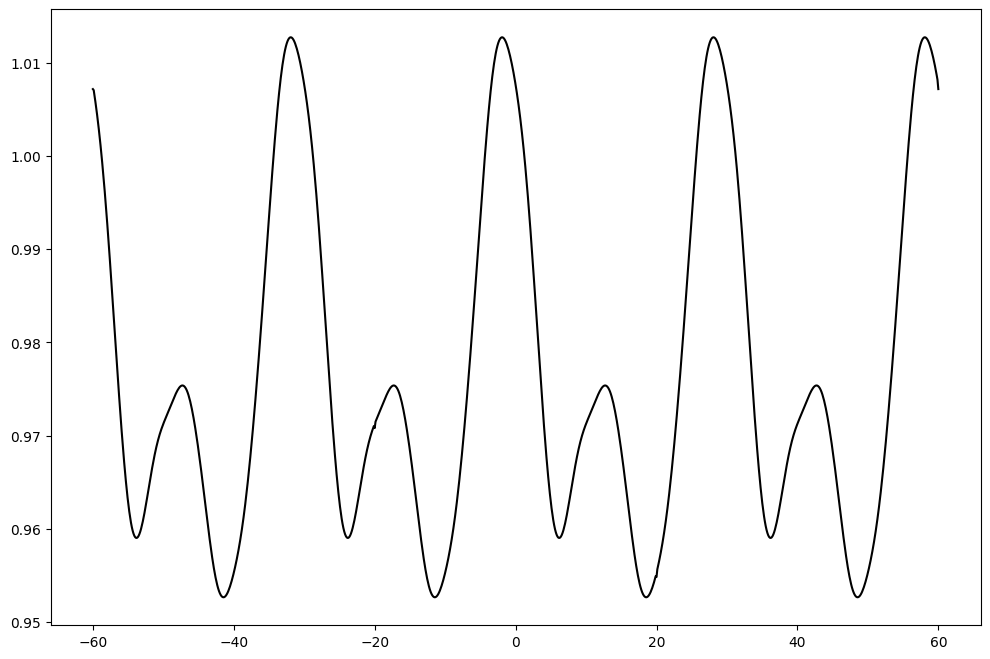

In [11]:
rng = np.random.default_rng(302592346730275158208684369480422136411)
t = np.linspace(-60, 60, 1000)
theta = (360 * t / 30) % 360
# Instantiate maps at low and high degree
star = Star(t=t, ydeg=15, smoothing=0.1)
star.planet.porb = 5.
star.planet.t0 = 0.
star.planet.inc = 95.
star.star.prot = 30
y = star.get_y()
star.map[:,:] = y.eval()
flux = star.sys.design_matrix(t)[:,:-1] @ y.eval()
plt.figure(figsize=(12,8))
plt.plot(t, flux, 'k-')

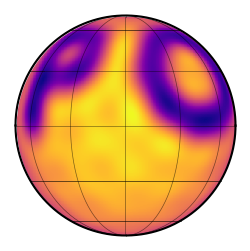

In [13]:
stars = [None]
y = [None]

for n, obl in enumerate(obls):
    stars[n] = Star(t=t, ydeg=15, smoothing=0.1)
    stars[n].reset()
    stars[n].map.obl = obl
    y = stars[n].get_y()
    stars[n].map[:,:] = y.eval().reshape(-1)
    stars[n].map.load('spot')
    stars[n].map.show()

In [14]:
stars[0].planet.Omega = 10

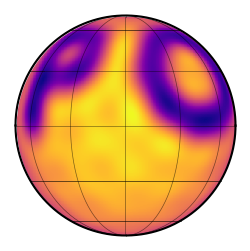

In [15]:
stars[0].map.load('spot')
stars[0].map.show()

In [16]:
sp = StarryProcess()

/Users/sabina/miniconda3/envs/starry-env/lib/python3.9/site-packages/starry_process/visualize.py:118: RuntimeWarning: invalid value encountered in true_divide
  theta -= (2 * theta + np.sin(2 * theta) - np.pi * np.sin(lat)) / (


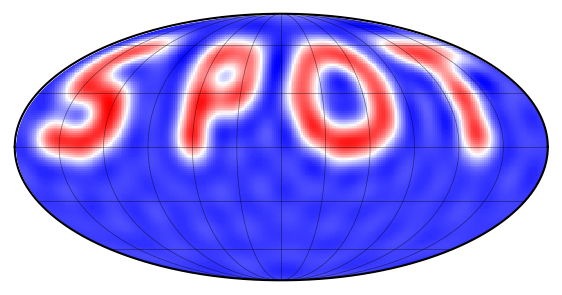

In [17]:
sp.visualize(stars[0].map.y, cmap='bwr_r')

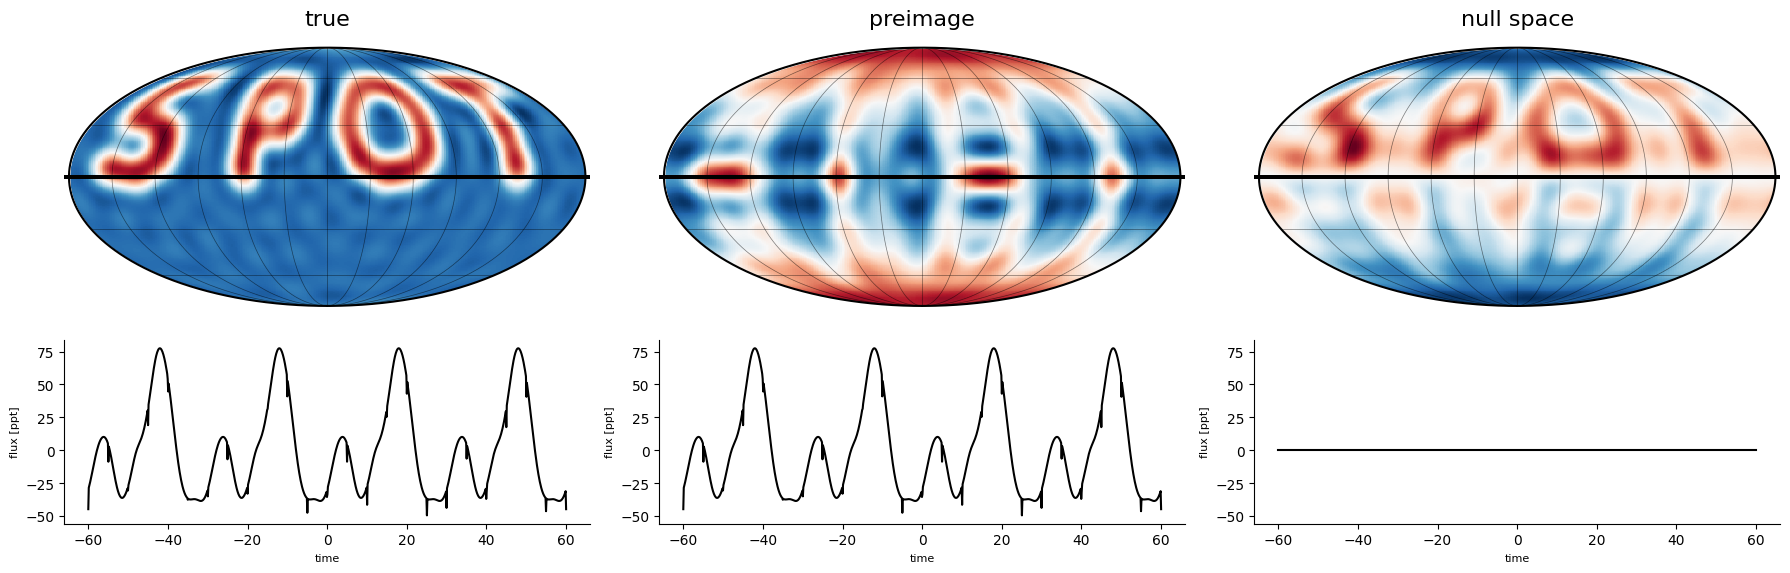

In [ ]:
stars = [None]
y = [None]

fig, ax = plt.subplots(
        2*len(stars), 3, figsize=(18, 6), gridspec_kw={"height_ratios": [1, 0.5] * len(stars)}
    )

for k, obl in enumerate(obls):
    
    # Compute the null space operators
    t = np.linspace(-60, 60, 1000)
    theta = (360 * t / 30) % 360
    stars[k] = Star(t=t, smoothing=0.1)
    stars[k].reset()
    stars[k].planet.Omega = obl
    stars[k].planet.porb = 5.
    stars[k].planet.t0 = 0.
    stars[k].star.prot = 30
    
    A = stars[k].sys.design_matrix(t)[:, :-1]
    rank = np.linalg.matrix_rank(A)
    _, _, VT = svd(A)
    N = VT[rank:].T @ VT[rank:]  # null space operator
    R = VT[:rank].T @ VT[:rank]  # row space operator


    # True map
    stars[k].map.load('spot')
    y[k] = stars[k].map.y
    image = stars[k].map.render(projection="moll")
    image += 1 - np.nanmedian(image)

    xo, yo, zo = stars[k].sys.position(t)
    xo = xo[1]
    yo = yo[1]
    zo = zo[1]
    idx = (zo > 0) | (xo ** 2 + yo ** 2 > 1)

    ax[k*2, 0].plot(xo[idx], yo[idx], "k-", ms=1);
    ax[k*2, 0].set_aspect(1)
    ax[k*2, 0].axis("off")

    ax[k*2, 1].plot(xo[idx], yo[idx], "k-", ms=1);
    ax[k*2, 1].set_aspect(1)
    ax[k*2, 1].axis("off")

    ax[k*2, 2].plot(xo[idx], yo[idx], "k-", ms=1);
    ax[k*2, 2].set_aspect(1)
    ax[k*2, 2].axis("off")


    stars[k].map.show(ax=ax[k*2, 0], image=image, projection="moll", cmap='RdBu')
    ax[0, 0].annotate(
        "true",
        xy=(0.5, 1.0),
        xycoords="axes fraction",
        xytext=(0, 10),
        textcoords="offset points",
        va="bottom",
        ha="center",
        fontsize=16,
    )

    flux = stars[k].sys.design_matrix(t)[:, :-1] @ y[k]
    flux -= np.mean(flux)
    flux *= 1e3
    ax[k * 2 + 1, 0].plot(t, flux, color='k')
    ymax = 1.2 * np.max(np.abs(flux))
 

    # row space only
    stars[k].map[:, :] = R @ y[k]
    image = stars[k].map.render(projection="moll")
    image += 1 - np.nanmedian(image)
    stars[k].map.show(ax=ax[k*2, 1], image=image, projection="moll", cmap='RdBu')
    ax[0, 1].annotate(
        "preimage",
        xy=(0.5, 1.0),
        xycoords="axes fraction",
        xytext=(0, 10),
        textcoords="offset points",
        va="bottom",
        ha="center",
        fontsize=16,
    )

    flux = stars[k].sys.design_matrix(t)[:, :-1] @ (R @ y[k])
    flux -= np.mean(flux)
    flux *= 1e3

    ax[k*2+1, 1].plot(t, flux, color='k')

    ax[k*2+1, 1].set_ylim(*ax[1, 0].get_ylim())

    # Null space only
    stars[k].map[:, :] = N @ y[k]
    image = stars[k].map.render(projection="moll")
    image += 1 - np.nanmedian(image)
    stars[k].map.show(ax=ax[k*2, 2], image=image, projection="moll", cmap='RdBu')
    ax[0, 2].annotate(
        "null space",
        xy=(0.5, 1.0),
        xycoords="axes fraction",
        xytext=(0, 10),
        textcoords="offset points",
        va="bottom",
        ha="center",
        fontsize=16,
    )

    flux = stars[k].sys.design_matrix(t)[:, :-1] @ (N @ y[k])
    flux -= np.mean(flux)
    flux *= 1e3

    ax[k*2+1, 2].plot(t, flux, color='k')

    ax[k*2+1, 2].set_ylim(*ax[1, 0].get_ylim())

    # Appearance
    for n in range(3):
        ax[k*2+1, n].spines["top"].set_visible(False)
        ax[k*2+1, n].spines["right"].set_visible(False)
        ax[k*2+1, n].set_xlabel("time", fontsize=8)
        ax[k*2+1, n].set_ylabel("flux [ppt]", fontsize=8)
        ax[k*2, n].set_rasterization_zorder(2)
    
    # Remove empty space between subplots
    plt.tight_layout()


100%|██████████| 1/1 [01:10<00:00, 70.41s/it]


Text(0, 0.5, 'variance reduction')

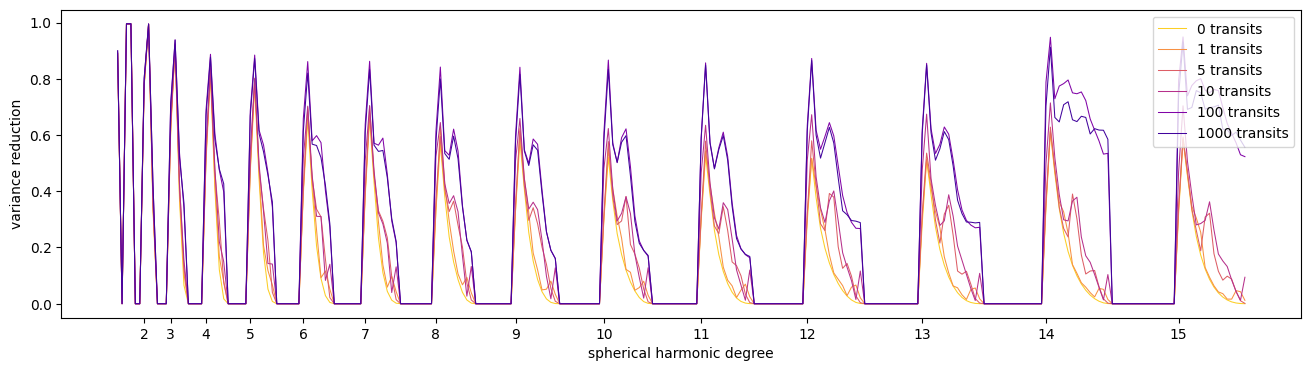

In [20]:
# Settings
ntheta = 50
ydeg = 15
ydeg_pad = 3
L = 1e9
C = 1
ninc = [1]
kpn = 300
clobber = False

ntran = [0, 1, 5, 10, 100, 1000]

cmap = plt.get_cmap("plasma_r")
color = lambda i: cmap(0.1 + 0.8 * i / (len(ntran) - 1))


S = np.empty((len(ninc), len(ntran), star.map.Ny))
np.random.seed(0)
for n in tqdm(
    range(len(ninc)), disable=bool(int(os.getenv("NOTQDM", "0")))
):
    for k in range(len(ntran)):
        t = np.linspace(-60, 60, 1000)
        theta = (360 * t / 30) % 360
        starp = Star(t=t, ydeg=15, smoothing=0.1)
        if k == 0:
            starp.planet.porb = 0
        else:
            starp.planet.porb = 120 / ntran[k]
        starp.planet.t0 = 0.
        starp.star.prot = 30
        y = starp.get_y()
        starp.map[:,:] = y.eval()
        
        A = np.empty((0, starp.map.Ny))
        A = np.vstack((A, starp.sys.design_matrix(t=t)[:,:-1]))
        cho_C = starry.linalg.solve(
            design_matrix=A,
            data=np.random.randn(A.shape[0]),
            C=C,
            L=L,
            N=starp.map.Ny,
        )[1]
        S[n, k] = 1 - np.diag(cho_C @ cho_C.T) / L
S = np.array(S, dtype="float32")


# Plot for just a *single* orientation
fig, ax = plt.subplots(1, figsize=(16, 4))
for k in range(len(ntran)):
    ax.plot(S[0, k], color=color(k), lw=0.75, alpha=1, zorder=-1, label=str(ntran[k])+" transits")
ax.set_rasterization_zorder(0)

# Modify the legend size and position
legend = ax.legend(fontsize=0.5, borderaxespad=0.1)
legend.get_frame().set_alpha(0.5)  

# Place the legend in the upper right corner
ax.legend(loc='upper right')

l = np.arange(2, ydeg + 1)
ax.set_xticks(l ** 2 + l)
ax.set_xticklabels(["{}".format(l) for l in np.arange(2, ydeg + 1)])
ax.set_xlabel("spherical harmonic degree")
ax.set_ylabel("variance reduction")
